# Eixo 5 — Hábitos Nocivos (Fumo e Álcool)

**Base:** Behavioral Risk Factor Surveillance System (BRFSS), 2015  
**Pergunta:** qual é a associação bruta do tabagismo e do consumo excessivo de álcool com diabetes e hipertensão?

Este notebook faz parte do projeto `eda-diabetes` e contém apenas a análise do Eixo 5. Os resultados são associações transversais e autorrelatadas; não demonstram causalidade.

## Preparação e verificação dos dados

O notebook localiza automaticamente o CSV na pasta `dataset` da raiz do projeto, mesmo quando a execução é iniciada dentro da subpasta da análise.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    pass  # O executor de validação injeta uma função display equivalente.

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 6), "axes.titlesize": 14, "axes.labelsize": 11})

nome_dataset = "diabetes_binary_health_indicators_BRFSS2015.csv"
candidatos = [Path(nome_dataset), Path("dataset") / nome_dataset, Path("../../dataset") / nome_dataset]
candidatos += [p / "dataset" / nome_dataset for p in [Path.cwd(), *Path.cwd().parents]]
DATA_PATH = next((p.resolve() for p in candidatos if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Dataset não encontrado. Mantenha a pasta dataset na raiz do projeto.")

df = pd.read_csv(DATA_PATH)
variaveis = [
    "Diabetes_binary", "HighBP", "Smoker", "HvyAlcoholConsump",
    "PhysHlth", "MentHlth", "GenHlth", "DiffWalk"
]
ausentes = [v for v in variaveis if v not in df.columns]
if ausentes:
    raise ValueError(f"Variáveis ausentes no dataset: {ausentes}")

resumo_base = pd.DataFrame({
    "Indicador": ["Linhas", "Colunas", "Valores ausentes nas variáveis usadas", "Linhas duplicadas completas"],
    "Valor": [len(df), df.shape[1], int(df[variaveis].isna().sum().sum()), int(df.duplicated().sum())]
})
display(resumo_base)
display(df[variaveis].describe().T.round(2))

,Indicador,Valor
0,Linhas,253680
1,Colunas,22
2,Valores ausentes nas variáveis usadas,0
3,Linhas duplicadas completas,24206


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.43,0.49,0.0,0.0,0.0,1.0,1.0
Smoker,253680.0,0.44,0.50,0.0,0.0,0.0,1.0,1.0
HvyAlcoholConsump,253680.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
PhysHlth,253680.0,4.24,8.72,0.0,0.0,0.0,3.0,30.0
MentHlth,253680.0,3.18,7.41,0.0,0.0,0.0,2.0,30.0
GenHlth,253680.0,2.51,1.07,1.0,2.0,2.0,3.0,5.0
DiffWalk,253680.0,0.17,0.37,0.0,0.0,0.0,0.0,1.0


A ausência de valores nulos nas variáveis selecionadas dispensa imputação. Registros idênticos são mantidos: em uma pesquisa populacional, respostas iguais não significam necessariamente duplicação da mesma pessoa, pois o arquivo não contém identificador individual.

## 2. Funções auxiliares

Para cada par exposição–desfecho binário, calculamos:

- prevalência do desfecho nos grupos exposto e não exposto;
- diferença absoluta em pontos percentuais;
- **PR** (razão de prevalências) e **OR** (odds ratio), com IC95%;
- teste exato de Fisher e V de Cramér.

A PR é a medida principal por ser mais diretamente interpretável em um estudo transversal. OR é apresentada como medida complementar e pode parecer mais extrema quando o desfecho é comum.

In [2]:
def associacao_binaria(dados, exposicao, desfecho, nome_exposicao, nome_desfecho):
    tab = pd.crosstab(dados[exposicao], dados[desfecho]).reindex(
        index=[0, 1], columns=[0, 1], fill_value=0
    )
    a, b = int(tab.loc[1, 1]), int(tab.loc[1, 0])
    c, d = int(tab.loc[0, 1]), int(tab.loc[0, 0])
    n1, n0 = a + b, c + d
    p1, p0 = a / n1, c / n0

    pr = p1 / p0
    se_log_pr = np.sqrt((1 / a) - (1 / n1) + (1 / c) - (1 / n0))
    pr_ic = np.exp(np.log(pr) + np.array([-1, 1]) * 1.96 * se_log_pr)

    or_ = (a * d) / (b * c)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    or_ic = np.exp(np.log(or_) + np.array([-1, 1]) * 1.96 * se_log_or)

    _, p_fisher = stats.fisher_exact([[a, b], [c, d]])
    chi2, _, _, _ = stats.chi2_contingency(tab, correction=False)
    v_cramer = np.sqrt(chi2 / tab.to_numpy().sum())

    return {
        "Exposição": nome_exposicao,
        "Desfecho": nome_desfecho,
        "n expostos": n1,
        "Prev. expostos (%)": 100 * p1,
        "Prev. não expostos (%)": 100 * p0,
        "Diferença (p.p.)": 100 * (p1 - p0),
        "PR": pr,
        "IC95% PR": f"{pr_ic[0]:.2f}–{pr_ic[1]:.2f}",
        "OR": or_,
        "IC95% OR": f"{or_ic[0]:.2f}–{or_ic[1]:.2f}",
        "V de Cramér": v_cramer,
        "p-valor (Fisher)": p_fisher,
    }


def tabela_2x2(dados, exposicao, desfecho, rotulo_exposicao, rotulo_desfecho):
    ct = pd.crosstab(dados[exposicao], dados[desfecho]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    pct = ct.div(ct.sum(axis=1), axis=0).mul(100)
    saida = ct.astype(int).astype(str) + " (" + pct.round(2).astype(str) + "%)"
    saida.index = [f"{rotulo_exposicao}: não", f"{rotulo_exposicao}: sim"]
    saida.columns = [f"Sem {rotulo_desfecho}", f"Com {rotulo_desfecho}"]
    return saida

# Eixo 5 — Hábitos Nocivos (Fumo e Álcool)

**Pergunta:** qual é a associação bruta do tabagismo e do consumo excessivo de álcool com diabetes e hipertensão?

`Smoker` indica ter fumado pelo menos 100 cigarros ao longo da vida. `HvyAlcoholConsump` usa o critério da pesquisa para consumo elevado; portanto, não representa qualquer consumo de álcool nem sua intensidade exata.

In [3]:
analises_e5 = [
    ("Smoker", "Diabetes_binary", "Tabagismo", "diabetes"),
    ("Smoker", "HighBP", "Tabagismo", "hipertensão"),
    ("HvyAlcoholConsump", "Diabetes_binary", "Consumo excessivo de álcool", "diabetes"),
    ("HvyAlcoholConsump", "HighBP", "Consumo excessivo de álcool", "hipertensão"),
]

resultados_e5 = pd.DataFrame([
    associacao_binaria(df, exp, out, nome_exp, nome_out)
    for exp, out, nome_exp, nome_out in analises_e5
])

colunas_num = ["Prev. expostos (%)", "Prev. não expostos (%)", "Diferença (p.p.)", "PR", "OR", "V de Cramér"]
exibicao_e5 = resultados_e5.copy()
exibicao_e5[colunas_num] = exibicao_e5[colunas_num].round(3)
exibicao_e5["p-valor (Fisher)"] = exibicao_e5["p-valor (Fisher)"].map(lambda x: "<0,001" if x < 0.001 else f"{x:.3f}".replace(".", ","))
display(exibicao_e5)

print("Tabela 2×2 — tabagismo × diabetes")
display(tabela_2x2(df, "Smoker", "Diabetes_binary", "Fumante", "diabetes"))
print("Tabela 2×2 — tabagismo × hipertensão")
display(tabela_2x2(df, "Smoker", "HighBP", "Fumante", "hipertensão"))
print("Tabela 2×2 — consumo excessivo de álcool × diabetes")
display(tabela_2x2(df, "HvyAlcoholConsump", "Diabetes_binary", "Consumo excessivo", "diabetes"))
print("Tabela 2×2 — consumo excessivo de álcool × hipertensão")
display(tabela_2x2(df, "HvyAlcoholConsump", "HighBP", "Consumo excessivo", "hipertensão"))

,Exposição,Desfecho,n expostos,Prev. expostos (%),Prev. não expostos (%),Diferença (p.p.),PR,IC95% PR,OR,IC95% OR,V de Cramér,p-valor (Fisher)
0,Tabagismo,diabetes,112423,16.293,12.055,4.238,1.352,1.33–1.38,1.420,1.39–1.45,0.061,"<0,001"
1,Tabagismo,hipertensão,112423,48.281,38.618,9.663,1.250,1.24–1.26,1.484,1.46–1.51,0.097,"<0,001"
2,Consumo excessivo de álcool,diabetes,14256,5.836,14.415,-8.579,0.405,0.38–0.43,0.368,0.34–0.40,0.057,"<0,001"
3,Consumo excessivo de álcool,hipertensão,14256,42.095,42.948,-0.854,0.980,0.96–1.00,0.966,0.93–1.00,0.004,"0,046"


Tabela 2×2 — tabagismo × diabetes


,Sem diabetes,Com diabetes
Fumante: não,124228 (87.94%),17029 (12.06%)
Fumante: sim,94106 (83.71%),18317 (16.29%)


Tabela 2×2 — tabagismo × hipertensão


,Sem hipertensão,Com hipertensão
Fumante: não,86707 (61.38%),54550 (38.62%)
Fumante: sim,58144 (51.72%),54279 (48.28%)


Tabela 2×2 — consumo excessivo de álcool × diabetes


,Sem diabetes,Com diabetes
Consumo excessivo: não,204910 (85.58%),34514 (14.42%)
Consumo excessivo: sim,13424 (94.16%),832 (5.84%)


Tabela 2×2 — consumo excessivo de álcool × hipertensão


,Sem hipertensão,Com hipertensão
Consumo excessivo: não,136596 (57.05%),102828 (42.95%)
Consumo excessivo: sim,8255 (57.91%),6001 (42.09%)


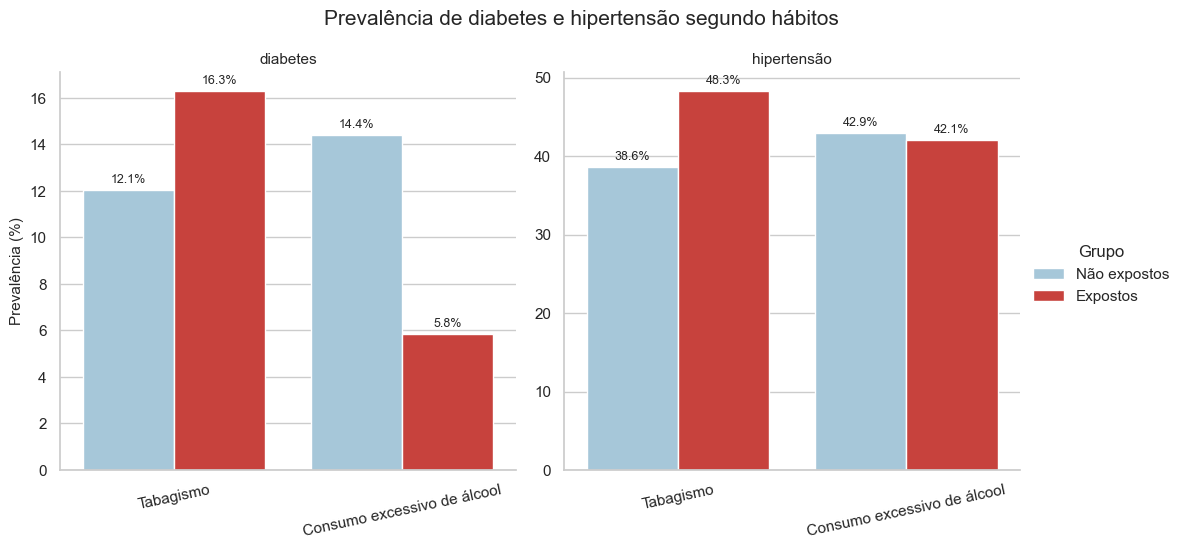

In [4]:
graf_e5 = resultados_e5.melt(
    id_vars=["Exposição", "Desfecho"],
    value_vars=["Prev. não expostos (%)", "Prev. expostos (%)"],
    var_name="Grupo", value_name="Prevalência (%)"
)
graf_e5["Grupo"] = graf_e5["Grupo"].map({
    "Prev. não expostos (%)": "Não expostos",
    "Prev. expostos (%)": "Expostos"
})

g = sns.catplot(
    data=graf_e5, x="Exposição", y="Prevalência (%)", hue="Grupo",
    col="Desfecho", kind="bar", height=5, aspect=1.05,
    palette=["#9ecae1", "#de2d26"], sharey=False
)
g.set_axis_labels("", "Prevalência (%)")
g.set_titles("{col_name}")
g.fig.suptitle("Prevalência de diabetes e hipertensão segundo hábitos", y=1.05, fontsize=15)
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=12)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)
plt.show()

### Interpretação do Eixo 5

- Entre pessoas classificadas como fumantes, a prevalência foi maior tanto para diabetes quanto para hipertensão. A PR quantifica essa diferença relativa; o V de Cramér ajuda a não confundir p-valores muito pequenos — favorecidos pelo grande tamanho amostral — com associações necessariamente fortes.
- O consumo excessivo de álcool apresentou prevalência bruta de diabetes menor e diferença pequena para hipertensão. **Isso não autoriza interpretar álcool como fator protetor.** O achado pode refletir diferenças de idade e sexo, sobrevivência, diagnóstico prévio, redução do consumo após adoecimento e outros confundidores não controlados.
- O EDA responde “como os grupos diferem nesta amostra”, não “qual hábito causou a doença”. Uma etapa confirmatória deveria usar regressão ajustada por idade, sexo, IMC, renda, escolaridade e outros fatores.